In [1]:
import sys
print(sys.executable)
%load_ext autoreload
%autoreload 2

d:\anaconda3\envs\dl\python.exe


这里采用在Mini-ImageNet上训练的VQ-VAE模型，将训练集数据编码为indices并保存，再用一个PixelCNN学习生成这些indices。
最后让PixelCNN采样生成indices，丢进VQ-VAE去decode

# 1. 导包+全局变量

### 1.1 导包

In [2]:
import GetData
import Model
import Train

import torch 
from torch.utils.data import TensorDataset,DataLoader
import numpy as np

import matplotlib.pyplot as plt
from tqdm import tqdm


### 1.2 全局变量

In [3]:
EPOCHS=10
PRINT_EPOC=1
BATCH_SIZE=128
lr=5e-4
wd=1e-5

device="cuda:0" if torch.cuda.is_available() else "cpu"
IN_CHANNELS=3
HIDDEN_CHANNELS=128
OUT_CHANNELS=3
RESIDUAL_CHANNELS=32
RESIDUAL_LAYERS=2
NUM_EMBEDDINGS=512    
EMBEDDING_DIM=64
DECAY=0.99
COMMIT_COST=0.25
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]

INDICES_H = 32
INDICES_W = 32

# 2. 加载VQ-VAE模型

In [4]:
# 加载模型：从 checkpoint 读取在Mini-ImageNet上训练得到的最佳模型作为初始权重
import os

CKPT_PATH=r"..\checkpoints\best_vqvae_MiniImageNet.pt"
checkpoint=torch.load(CKPT_PATH,map_location=device,weights_only=False)
cfg=checkpoint["config"]

vqvae_model=Model.Model(
    cfg["IN_CHANNELS"],cfg["HIDDEN_CHANNELS"],cfg["OUT_CHANNELS"],
    cfg["RESIDUAL_CHANNELS"],cfg["RESIDUAL_LAYERS"],
    cfg["NUM_EMBEDDINGS"],cfg["EMBEDDING_DIM"],cfg["DECAY"],cfg["COMMIT_COST"]
)
vqvae_model.load_state_dict(checkpoint["model_state_dict"])
vqvae_model=vqvae_model.to(device)

print(f"loaded best Mini-ImageNet model from: {CKPT_PATH}")
print(f"saved best loss: {checkpoint.get('best_loss',float('nan')):.6f}")

loaded best Mini-ImageNet model from: ..\checkpoints\best_vqvae_MiniImageNet.pt
saved best loss: 0.062413


# 3. 获取数据加载器 + 生成每个图像的indices

### 3.1 获取原始图像的数据加载器

In [5]:
train_loader,valid_loader,test_loader=GetData.get_MiniImageNet(BATCH_SIZE,image_size=128)

# n-code -> 英文短名（mini-ImageNet Ravi split 全部 100 个类别）
_NCODE_TO_NAME = {
    # ---- train (64) ----
    "n01532829": "house finch", "n01558993": "robin", "n01704323": "triceratops",
    "n01749939": "green mamba", "n01770081": "harvestman", "n01843383": "toucan",
    "n01910747": "jellyfish", "n02074367": "dugong", "n02089867": "Walker hound",
    "n02091831": "Saluki", "n02101006": "Gordon setter", "n02105505": "komondor",
    "n02108089": "boxer", "n02108551": "Tibetan mastiff", "n02108915": "French bulldog",
    "n02111277": "Newfoundland", "n02113712": "miniature poodle", "n02120079": "Arctic fox",
    "n02165456": "ladybug", "n02457408": "three-toed sloth", "n02606052": "rock beauty",
    "n02687172": "aircraft carrier", "n02747177": "ashcan", "n02795169": "barrel",
    "n02823428": "beer bottle", "n02966193": "carousel", "n03017168": "chime",
    "n03047690": "clog", "n03062245": "cocktail shaker", "n03207743": "dishrag",
    "n03220513": "dome", "n03337140": "file", "n03347037": "fire screen",
    "n03400231": "frying pan", "n03476684": "hair slide", "n03527444": "holster",
    "n03676483": "lipstick", "n03838899": "oboe", "n03854065": "organ",
    "n03888605": "parallel bars", "n03908618": "pencil box", "n03924679": "photocopier",
    "n03998194": "prayer rug", "n04067472": "reel", "n04243546": "slot",
    "n04251144": "snorkel", "n04258138": "solar dish", "n04275548": "spider web",
    "n04296562": "stage", "n04389033": "tank", "n04435653": "tile roof",
    "n04443257": "tobacco shop", "n04509417": "unicycle", "n04515003": "upright piano",
    "n04596742": "wok", "n04604644": "worm fence", "n04612504": "yawl",
    "n06794110": "street sign", "n07584110": "consomme", "n07697537": "hotdog",
    "n07747607": "orange", "n09246464": "cliff", "n13054560": "bolete",
    "n13133613": "corn ear",
    # ---- valid (16) ----
    "n01855672": "goose", "n02091244": "Ibizan hound", "n02114548": "white wolf",
    "n02138441": "meerkat", "n02174001": "rhinoceros beetle", "n02950826": "cannon",
    "n02971356": "carton", "n02981792": "catamaran", "n03075370": "combination lock",
    "n03417042": "garbage truck", "n03535780": "horizontal bar", "n03584254": "iPod",
    "n03770439": "miniskirt", "n03773504": "missile", "n03980874": "poncho",
    "n09256479": "coral reef",
    # ---- test (20) ----
    "n01930112": "nematode", "n01981276": "king crab", "n02099601": "golden retriever",
    "n02110063": "malamute", "n02110341": "dalmatian", "n02116738": "African hunting dog",
    "n02129165": "lion", "n02219486": "ant", "n02443484": "black-footed ferret",
    "n02871525": "bookshop", "n03127925": "crate", "n03146219": "cuirass",
    "n03272010": "electric guitar", "n03544143": "hourglass", "n03775546": "mixing bowl",
    "n04146614": "school bus", "n04149813": "scoreboard", "n04418357": "theater curtain",
    "n04522168": "vase", "n07613480": "trifle",
}

# 拼装统一的 {idx: english_name}：train 占 0-63，valid 占 64-79，test 占 80-99。
# 这样 train_loader 的标签可直接查；valid/test 用 SPLIT_OFFSET 加偏移即可。
SPLIT_OFFSET = {"train": 0, "valid": 64, "test": 80}
Mini_ImageNet_map = {}
for split, loader in [("train", train_loader),
                      ("valid", valid_loader),
                      ("test",  test_loader)]:
    offset = SPLIT_OFFSET[split]
    for ncode, local_idx in loader.dataset.class_to_idx.items():
        Mini_ImageNet_map[offset + local_idx] = _NCODE_TO_NAME[ncode]

assert len(Mini_ImageNet_map) == 100
print(f"Mini_ImageNet_map: {len(Mini_ImageNet_map)} classes, "
      f"sample -> 0: {Mini_ImageNet_map[0]}, 64: {Mini_ImageNet_map[64]}, 80: {Mini_ImageNet_map[80]}")

Mini_ImageNet_map: 100 classes, sample -> 0: house finch, 64: goose, 80: nematode


### 3.2 把原始图像变为隐变量

In [ ]:

vqvae_model=vqvae_model.to(device)
vqvae_model.eval()

all_indices = []
all_labels = []

with torch.no_grad():
    for split, loader in [("train", train_loader), ("valid", valid_loader), ("test", test_loader)]:
        offset = SPLIT_OFFSET[split]
        for images, labels in tqdm(loader, desc=f"生成所有indices in {split}"):
            images = images.to(device)
            indices = vqvae_model.encode(images)  # (B, 32, 32)
            all_indices.append(indices.cpu())
            all_labels.append(labels + offset)  # 局部标签 -> 全局 0-99

all_indices = torch.cat(all_indices, dim=0)
all_labels = torch.cat(all_labels, dim=0)
print(f"生成完成！总共有 {len(all_indices)} 个indices样本")
print(f"每个样本形状：{all_indices.shape[1:]}")  # 应该输出 torch.Size([32, 32])
print(f"标签范围：{all_labels.min().item()} ~ {all_labels.max().item()}，"
      f"唯一类别数：{len(torch.unique(all_labels))}")

# 保存到硬盘，下次不用重新生成
torch.save(all_indices, r"..\checkpoints\vqvae_indices_dataset.pt")
torch.save(all_labels, r"..\checkpoints\vqvae_labels_dataset.pt")
print("indices数据集已保存到 vqvae_indices_dataset.pt")
print("labels数据集已保存到 vqvae_labels_dataset.pt")

生成所有indices in test: 100%|██████████| 94/94 [00:56<00:00,  1.66it/s]


生成完成！总共有 60000 个indices样本
每个样本形状：torch.Size([32, 32])
标签范围：0 ~ 99，唯一类别数：100
indices数据集已保存到 vqvae_indices_dataset.pt
labels数据集已保存到 vqvae_labels_dataset.pt


### 3.3 把隐变量变为数据加载器

In [6]:

INDICES_PATH = r"..\checkpoints\vqvae_indices_dataset.pt"
LABELS_PATH  = r"..\checkpoints\vqvae_labels_dataset.pt"

def _to_tensor(obj):
    """把加载结果统一规整为 torch.Tensor，兼容 tensor / list / tuple / ndarray。"""
    if isinstance(obj, torch.Tensor):
        return obj
    if isinstance(obj, (list, tuple)):
        if len(obj) == 0:
            raise ValueError("加载得到空的 list/tuple")
        if all(isinstance(x, torch.Tensor) for x in obj):
            return torch.cat(obj, dim=0)
        return torch.as_tensor(obj)
    if isinstance(obj, np.ndarray):
        return torch.from_numpy(obj)
    raise TypeError(f"无法将类型 {type(obj)} 转换为 Tensor")

if os.path.exists(INDICES_PATH) and os.path.exists(LABELS_PATH):
    # weights_only=False: 这些是我们自己存的纯数据，不需要新版默认的安全限制
    all_indices = _to_tensor(torch.load(INDICES_PATH, map_location="cpu", weights_only=False))
    all_labels  = _to_tensor(torch.load(LABELS_PATH,  map_location="cpu", weights_only=False))
    print(f"已从磁盘加载: {INDICES_PATH}, {LABELS_PATH}")
else:
    print("未找到磁盘缓存，使用 3.2 中内存里的 all_indices / all_labels")
    all_indices = _to_tensor(all_indices)
    all_labels  = _to_tensor(all_labels)

# PixelCNN 需要 long 类型的 token indices，分类条件标签也用 long
all_indices = all_indices.long()
all_labels  = all_labels.long()
assert len(all_indices) == len(all_labels), \
    f"indices 与 labels 长度不一致: {len(all_indices)} vs {len(all_labels)}"
n_unique_labels = len(torch.unique(all_labels))
assert n_unique_labels == 100, (
    f"标签仅有 {n_unique_labels} 个唯一值 (期望 100)。"
    "请重新运行上一个 cell 生成带 SPLIT_OFFSET 的全局标签。"
)
assert all_labels.min() >= 0 and all_labels.max() < 100, \
    f"标签超出 [0, 99]: {all_labels.min().item()} ~ {all_labels.max().item()}"
print(f"all_indices: {tuple(all_indices.shape)} {all_indices.dtype}")
print(f"all_labels : {tuple(all_labels.shape)} {all_labels.dtype}")
print(f"标签校验通过: 100 类, 范围 [{all_labels.min().item()}, {all_labels.max().item()}]")

# 划分训练集和验证集（9:1）
perm = torch.randperm(len(all_indices))
all_indices = all_indices[perm]
all_labels  = all_labels[perm]
train_size = int(0.9 * len(all_indices))
train_indices, val_indices = all_indices[:train_size], all_indices[train_size:]
train_labels,  val_labels  = all_labels[:train_size],  all_labels[train_size:]

train_set = TensorDataset(train_indices, train_labels)
valid_set = TensorDataset(val_indices,   val_labels)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"训练集大小：{len(train_indices)}")
print(f"验证集大小：{len(val_indices)}")

已从磁盘加载: ..\checkpoints\vqvae_indices_dataset.pt, ..\checkpoints\vqvae_labels_dataset.pt
all_indices: (60000, 32, 32) torch.int64
all_labels : (60000,) torch.int64
标签校验通过: 100 类, 范围 [0, 99]
训练集大小：54000
验证集大小：6000


# 4. 训练

### 4.1 定义模型

In [7]:
init_model=Model.GatedPixelCNN(
    input_dim=NUM_EMBEDDINGS,# 512
    dim=EMBEDDING_DIM,       # 64
    n_layers=20,            
    n_classes=100
)

In [8]:
import os

PRIOR_CKPT_PATH = r"..\checkpoints\best_pixelcnn_prior.pt"

if os.path.exists(PRIOR_CKPT_PATH):
    prior_ckpt = torch.load(PRIOR_CKPT_PATH, map_location=device, weights_only=False)
    init_model.load_state_dict(prior_ckpt["model_state_dict"],strict=False)
    init_model = init_model.to(device)
    print(f"已加载已有 PixelCNN prior: {PRIOR_CKPT_PATH}")
    print(f"上次保存的 best val loss: {prior_ckpt.get('best_loss', float('nan')):.6f}")
else:
    print(f"未找到 {PRIOR_CKPT_PATH}, 将从头训练")

已加载已有 PixelCNN prior: ..\checkpoints\best_pixelcnn_prior.pt
上次保存的 best val loss: 3.175110


### 4.2 模型训练

In [13]:
train_loss_list,valid_loss_list=[],[]

In [14]:
for i in range(1):
    print(f"==========EPOCH:{i*10+1}~{(i+1)*10}==========")
    init_model,train_loss,valid_loss=Train.train_prior(
        init_model,
        train_loader,valid_loader,
        1,PRINT_EPOC,
        lr,wd,device
    )
    train_loss_list.extend(train_loss)
    valid_loss_list.extend(valid_loss)

==========EPOCH:1~10==========
epoch: 1
train=3.1850  val=3.1751



In [15]:
best_model=init_model

### 4.3 训练损失可视化

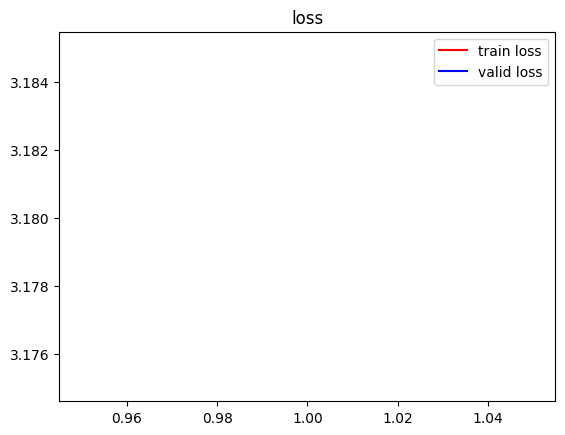

In [17]:
plt.plot(torch.arange(1,1+1),train_loss_list,"red",label="train loss")
plt.plot(torch.arange(1,1+1),valid_loss_list,"blue",label="valid loss")
plt.legend()
plt.title("loss")
plt.show()

### 4.4 模型

In [18]:
PRIOR_CKPT_PATH = r"..\checkpoints\best_pixelcnn_prior.pt"

prior_cfg = {
    "input_dim": NUM_EMBEDDINGS,
    "dim":       EMBEDDING_DIM,
    "n_layers":  20,
    "n_classes": 100,
}

best_val_loss = min(valid_loss_list) if len(valid_loss_list) > 0 else float("nan")

if os.path.exists(PRIOR_CKPT_PATH):
    prev_ckpt = torch.load(PRIOR_CKPT_PATH, map_location="cpu", weights_only=False)
    prev_best = prev_ckpt.get("best_loss", float("inf"))
else:
    prev_best = float("inf")

if best_val_loss < prev_best:
    os.makedirs(os.path.dirname(PRIOR_CKPT_PATH), exist_ok=True)
    torch.save({
        "model_state_dict": best_model.state_dict(),
        "config":           prior_cfg,
        "train_loss_list":  train_loss_list,
        "valid_loss_list":  valid_loss_list,
        "best_loss":        best_val_loss,
    }, PRIOR_CKPT_PATH)
    print(f"已保存新的最佳 PixelCNN prior 到: {PRIOR_CKPT_PATH}")
    print(f"  本次 best val loss: {best_val_loss:.6f}  (此前: {prev_best:.6f})")
else:
    print(f"本次 best val loss = {best_val_loss:.6f} 未优于已保存的 {prev_best:.6f}, 不覆盖")

已保存新的最佳 PixelCNN prior 到: ..\checkpoints\best_pixelcnn_prior.pt
  本次 best val loss: 3.175110  (此前: 3.178386)


# 5. 采样

### 5.1 加载最佳先验生成模型

In [9]:
prior_Model=Model.GatedPixelCNN(
    input_dim=NUM_EMBEDDINGS,
    dim=EMBEDDING_DIM,
    n_layers=20,
    n_classes=100
)
if os.path.exists(PRIOR_CKPT_PATH):
    prior_ckpt = torch.load(PRIOR_CKPT_PATH, map_location=device, weights_only=False)
    prior_Model.load_state_dict(prior_ckpt["model_state_dict"])
    prior_Model = prior_Model.to(device)
    print(f"已加载已有 PixelCNN prior: {PRIOR_CKPT_PATH}")
    print(f"上次保存的 best val loss: {prior_ckpt.get('best_loss', float('nan')):.6f}")

已加载已有 PixelCNN prior: ..\checkpoints\best_pixelcnn_prior.pt
上次保存的 best val loss: 3.175110


### 5.2 生成标签

In [26]:
labels=torch.tensor([43,19,23,33,41])
shape=(32,32)
bs=len(labels)
latent=prior_Model.generate(labels,shape,bs,0.95)



In [27]:
print(latent.shape)

print(latent[2])

torch.Size([5, 32, 32])
tensor([[118,   1,   1,  ...,   1,   1,   1],
        [344, 494,  82,  ..., 162, 162,   1],
        [428,  45,  52,  ..., 227,  62,   1],
        ...,
        [ 22, 136,  65,  ..., 267,  68, 169],
        [218, 488, 132,  ..., 443, 448, 366],
        [506, 170, 133,  ..., 192, 457, 500]], device='cuda:0')


### 5.3 生成图片

In [28]:
images=vqvae_model.decode(latent)
images=images.cpu().detach()
print(images.shape)
images=images.permute(0,2,3,1)
for i in range(3):  
    images[:,:,:,i]=images[:,:,:,i]*std[i]+mean[i]

torch.Size([5, 3, 128, 128])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04209131..1.0252472].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.008701533..1.1031644].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.014076084..1.1096612].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.06648946..1.0903858].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07291043..0.75388616].


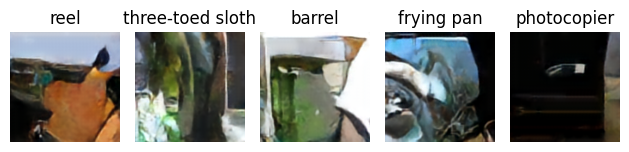

In [29]:
for i in range(bs):
    plt.subplot(1,bs,i+1)
    plt.imshow(images[i])
    plt.axis("off")
    plt.title(Mini_ImageNet_map[labels[i].item()])

plt.tight_layout()
plt.show()